# BLINKIT SALES ANALYSIS

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("blinkit_data.csv")

In [84]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [71]:
df.sample(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
2467,Regular,FDM58,Snack Foods,2011,OUT010,Tier 3,Small,Grocery Store,0.133385,16.85,109.8544,4.2
1064,Regular,FDI21,Snack Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.056603,5.59,63.2168,4.4
8215,Regular,FDJ27,Meat,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.122373,17.70,101.5674,4.0
1253,Regular,FDT10,Snack Foods,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.062297,16.70,60.6562,4.4
6810,Regular,FDO45,Snack Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.037953,13.15,89.5856,4.0
4686,Low Fat,FDE26,Canned,2011,OUT010,Tier 3,Medium,Grocery Store,0.148977,9.30,143.0786,3.6
4144,Low Fat,NCG43,Household,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.074542,20.20,94.1462,3.8
6225,Low Fat,FDL20,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.128614,17.10,111.6886,4.0
2733,Regular,FDT47,Breads,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.024547,5.26,95.7068,4.1
6189,Low Fat,FDA38,Dairy,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.025520,5.44,238.7538,4.0


In [85]:
df.shape

(8523, 12)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [87]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [88]:
(df['Item Weight'].isnull().sum() / len(df)) * 100

np.float64(17.165317376510618)

In [90]:
df['Item Weight'] = df['Item Weight'].fillna(df['Item Weight'].median())

In [91]:
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64

In [92]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [93]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat',
                                                         'low fat': 'Low Fat',
                                                         'reg': 'Regular'})


In [94]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [95]:
#Total Sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

#Number of items sold
items_sold = df['Sales'].count()

#Average Ratings
avg_ratings = df['Rating'].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Items Sold: {items_sold}")
print(f"Average Rating: {avg_ratings:,.1f}")

Total Sales: $1,201,681.48
Average Sales: $140.99
Items Sold: 8523
Average Rating: 4.0


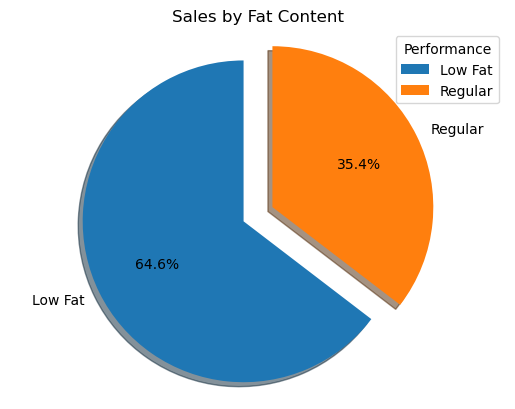

In [96]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels = sales_by_fat.index,
                       autopct = '%.1f%%',
                       startangle = 90, 
                       explode = [0.2, 0],
                       shadow = True)
plt.legend(title = "Performance")       
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

In [97]:
#Total Sales by Item Type

<function matplotlib.pyplot.show(close=None, block=None)>

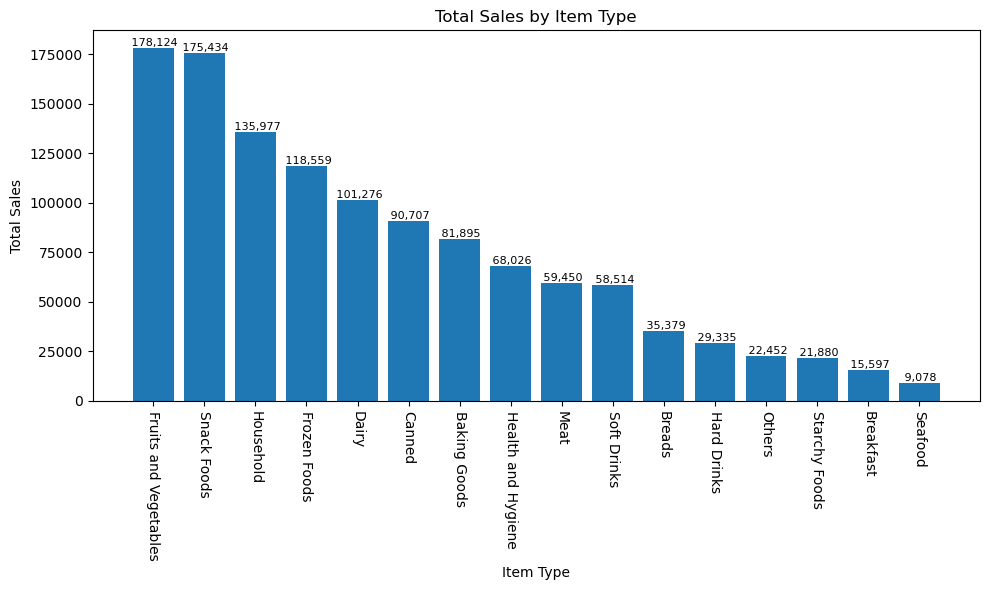

In [98]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize = (10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation = -90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')

plt.title("Total Sales by Item Type")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
            f' {bar.get_height():,.0f}' , ha = 'center' , va = 'bottom' , fontsize = 8)
    
plt.tight_layout()
plt.show

In [99]:
#Fat Content by Outlet

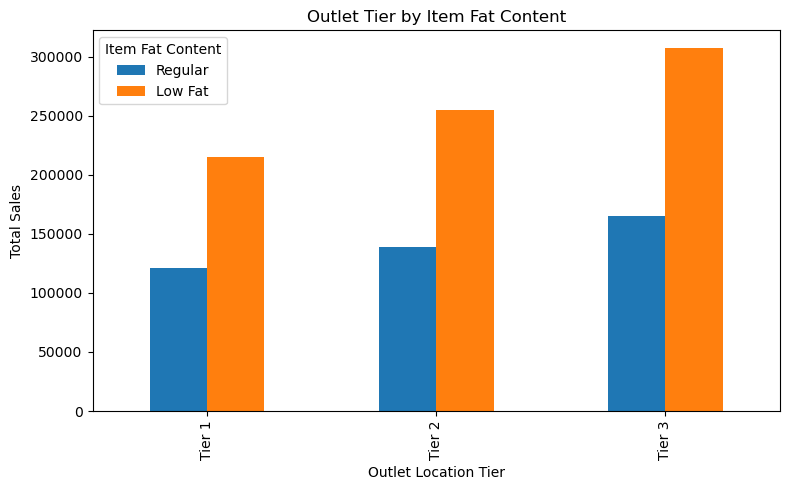

In [100]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular' , 'Low Fat']]

ax = grouped.plot(kind = 'bar' , figsize = (8,5) , title = 'Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()

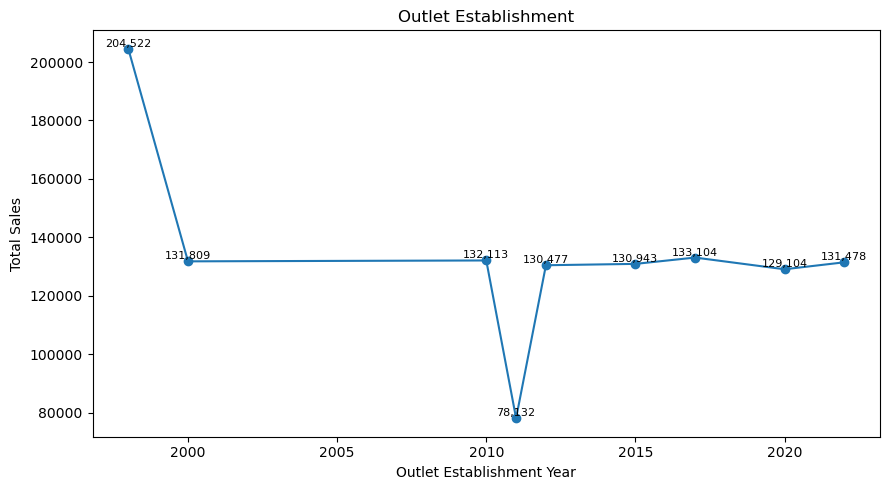

In [106]:
#Total sales by year
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize = (9,5))
plt.plot(sales_by_year.index , sales_by_year.values, marker = 'o' , linestyle = '-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}' , ha = 'center' , va = 'bottom' , fontsize = 8)

plt.tight_layout()
plt.show()

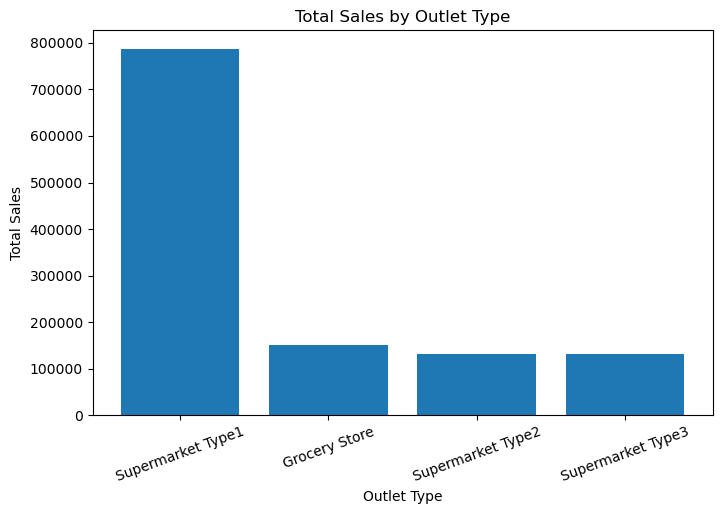

In [109]:
sales_by_outlet = df.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(sales_by_outlet.index, sales_by_outlet.values)
plt.xticks(rotation=20)
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Outlet Type")

plt.show()

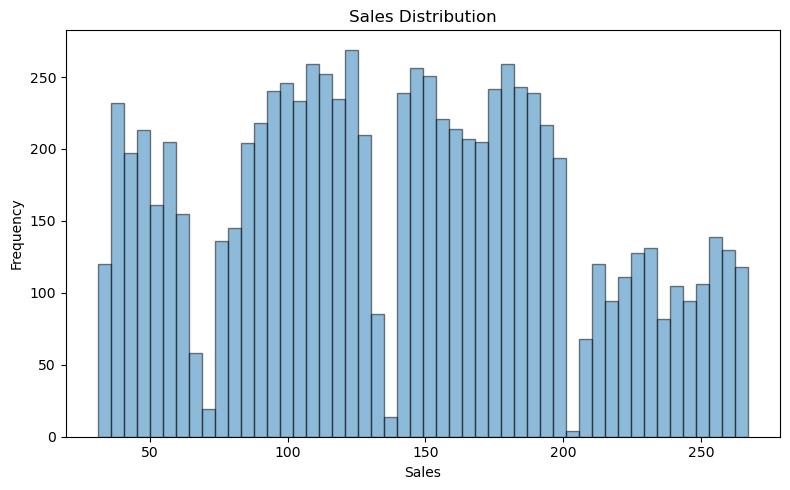

In [115]:
plt.figure(figsize = (8 , 5))

plt.hist(df['Sales'] , bins=50 , edgecolor = 'black' , alpha = 0.5)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

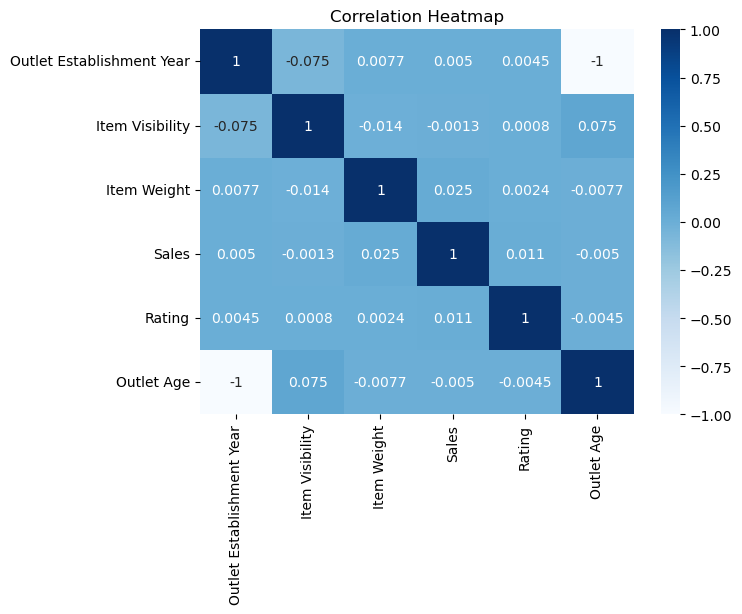

In [117]:
plt.figure(figsize = (7,5))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot = True,
            cmap = 'Blues')

plt.title("Correlation Heatmap")
plt.show()